# Notebook 02: Exploratory Data Analysis

Prepared by: Donyl Alcantara

### References used in this notebook
- Lunor, S.B.R. et al. (2023). Machine Learning Approach for Pump Price Prediction for the Philippines Post COVID-19. *Chemical Engineering Transactions*, 103, 265–270.
- Ljubić, H. et al. (2023). Exploratory Data Analysis and Prediction of Fuel Prices in FBiH. *AIST*.
- Wen, D. et al. (2025). Forecasting gasoline prices using oil prices: New evidence based on the rocket and feather hypothesis. *Energy*, 335, 138115.
- Caldara, D. & Iacoviello, M. (2022). Measuring Geopolitical Risk. *American Economic Review*, 112(4), 1194–1225.
- Hamilton, J.D. (1989). A New Approach to the Economic Analysis of Nonstationary Time Series. *Econometrica*, 57(2), 357–384.
- Truong, C., Oudre, L. & Vayatis, N. (2020). Selective review of offline change point detection methods. *Signal Processing*, 167, 107299.

### What this notebook establishes
This EDA notebook serves as the **analytical foundation** for all downstream modeling decisions. Every conclusion drawn here is propagated explicitly to Notebook 03 (Feature Engineering) via a decision table.

The analysis proceeds in six stages:
1. Data quality and missingness audit
2. Stationarity and integration order (motivates lag feature structure)
3. Lead-lag analysis: Crude oil features -> pump prices (motivates lag window selection)
4. Autocorrelation structure (motivates own-price lag inclusion)
5. Asymmetric price transmission — Rockets and Feathers (motivates asymmetric MOPS encoding)
6. Anomaly detection and regime segmentation (motivates crisis dummies and Markov regime feature)


## Section 1: Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, acf, pacf, ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import ruptures as rpt

# Global plot style 
FIGSIZE_WIDE  = (14, 4)
FIGSIZE_TALL  = (14, 14)
FIGSIZE_MED   = (14, 8)

plt.rcParams.update({
    'axes.spines.top':    False,
    'axes.spines.right':  False,
})

# Crisis period definitions (used consistently across all panels)
CRISIS_BANDS = [
    ('2020-03-09', '2020-06-15', '#4e79a7', 'COVID-19 Demand Collapse'),
    ('2022-02-24', '2022-12-31', '#e15759', 'Russia–Ukraine War Onset'),
    ('2026-01-01', '2026-04-30', '#f28e2b', 'Iran War (2026)'),
]

def shade_crises(ax, alpha=0.12):
    """Apply consistent crisis shading to any time-series axis."""
    for start, end, color, label in CRISIS_BANDS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color=color, alpha=alpha, label=label)

# ── Column name constants ─────────────────────────────────────────────────────
PUMP_PRICE_COLS  = ['diesel', 'diesel_plus', 'kerosene', 'ron91', 'ron95', 'ron97', 'ron100']
CRUDE_COLS       = ['brent_mean', 'wti_mean', 'dubai_close']
FEATURE_COLS     = ['brent_mean', 'usd_php_mean', 'mops_gasoil_mean',
                    'mops_rbob_mean', 'cpi_value', 'dubai_close']
PRIMARY_TARGET   = 'diesel'


## Section 2: Data Load & Coverage Audit

We load the master weekly panel assembled in Notebook 01. The panel is indexed on **Tuesday** of each week, aligned to the DOE weekly price bulletin release schedule. All rows with a Tuesday index date falling within the 2018–2026 window are retained.


In [2]:
df = pd.read_parquet('../data/final/master_weekly.parquet')

print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df.index.min().date()} → {df.index.max().date()}')
print(f'Total weeks   : {len(df)}')


Dataset shape : (373, 22)
Date range    : 2018-02-13 → 2026-04-28
Total weeks   : 373


### 2.1 Missingness Audit

Null values in pump price targets require explicit handling before modeling. Ljubić et al. (2023) used forward-fill for missing fuel price observations in their FBiH dataset, citing the administered-price nature of fuel markets where prices carry forward until an official adjustment. We adopt the same convention, with a `ffill` + `bfill` pass on all target columns. Any remaining nulls (e.g., `ron100`, which has 27 missing weeks due to market availability) are documented below.


In [3]:
# Null audit 
null_counts = df.isnull().sum().sort_values(ascending=False)
null_counts = null_counts[null_counts > 0]

print('Columns with missing values:')
print(null_counts.to_string())
print(f'\nComplete rows (zero nulls across all columns): {df.dropna().shape[0]} / {len(df)}')


Columns with missing values:
ron100         27
kerosene        3
diesel_plus     3
diesel          3

Complete rows (zero nulls across all columns): 346 / 373


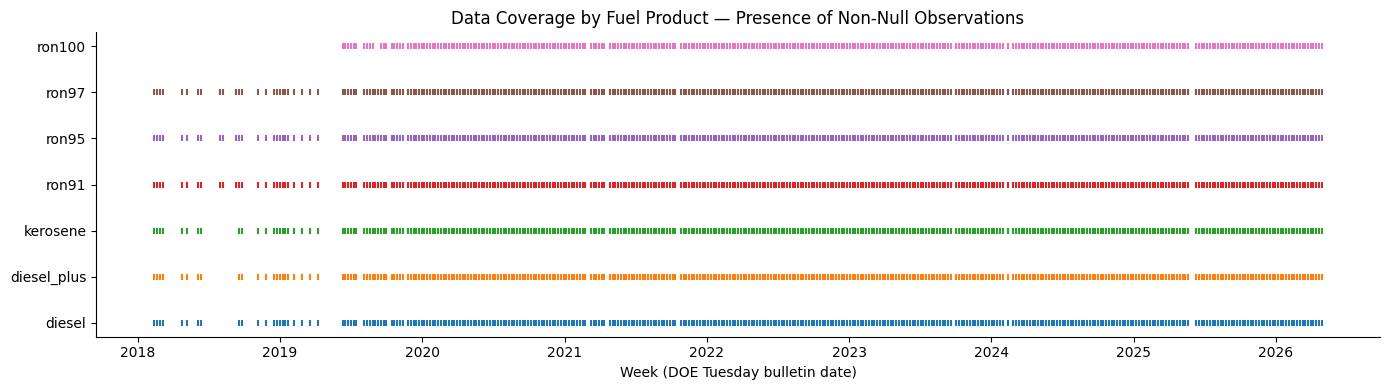

In [4]:
# Pump price target availability
available_targets = [c for c in PUMP_PRICE_COLS if c in df.columns]

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
for i, col in enumerate(available_targets):
    presence = df[col].notna().astype(int) * (i + 1)
    ax.scatter(df.index, presence.where(presence > 0),
               marker='|', s=15, label=col)

ax.set_yticks(range(1, len(available_targets) + 1))
ax.set_yticklabels(available_targets)
ax.set_xlabel('Week (DOE Tuesday bulletin date)')
ax.set_title('Data Coverage by Fuel Product — Presence of Non-Null Observations')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


## Section 3: Crude Oil Benchmark Correlation

We carry three crude oil series: Brent (global benchmark, daily), WTI (US-centric), and Dubai (Asian sour benchmark, monthly forward-filled). Lunor et al. (2023) selected Dubai as their crude feature because Philippine refiners price against the Asian complex. However, Dubai is monthly and is forward-filled across weeks — introducing artificial stationarity. Brent is daily and directly tradable.

**Decision rule:** if Brent-WTI Pearson r > 0.95, the two series are redundant. We retain Brent (daily granularity, more cited in the pass-through literature) and Dubai (robustness feature for the Asian refining margin). WTI is dropped.


In [5]:
# Crude oil correlation matrix
crude_available = [c for c in CRUDE_COLS if c in df.columns]
crude_df = df[crude_available].dropna()

print('Crude Oil Pearson Correlation Matrix')
print(crude_df.corr().round(4))

Crude Oil Pearson Correlation Matrix
             brent_mean  wti_mean  dubai_close
brent_mean       1.0000    0.9909       0.9582
wti_mean         0.9909    1.0000       0.9469
dubai_close      0.9582    0.9469       1.0000


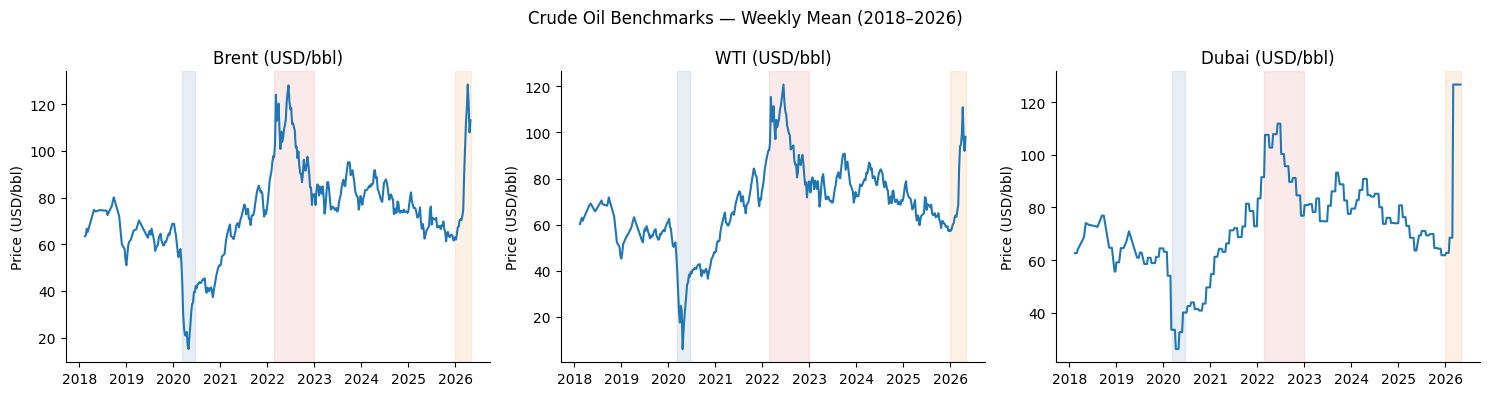

Brent–WTI Pearson r = 0.9909
→ Decision: DROP WTI (r > 0.95 — redundant with Brent)
  This is consistent with Lunor et al. (2023) who excluded WTI
  from their Philippine pump price models.


In [6]:
# Time-series comparison of crude benchmarks
fig, axes = plt.subplots(1, len(crude_available), figsize=(5 * len(crude_available), 4),
                         sharey=False)
if len(crude_available) == 1:
    axes = [axes]

colors = {'brent_mean': '#4e79a7', 'wti_mean': '#e15759', 'dubai_close': '#f28e2b'}
labels = {'brent_mean': 'Brent (USD/bbl)', 'wti_mean': 'WTI (USD/bbl)',
          'dubai_close': 'Dubai (USD/bbl)'}

for ax, col in zip(axes, crude_available):
    ax.plot(crude_df.index, crude_df[col])
    shade_crises(ax)
    ax.set_title(labels.get(col, col))
    ax.set_ylabel('Price (USD/bbl)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params()

plt.suptitle('Crude Oil Benchmarks — Weekly Mean (2018–2026)')
plt.tight_layout()
plt.show()

# Drop WTI decision
if 'brent_mean' in crude_df and 'wti_mean' in crude_df:
    r_brent_wti = crude_df['brent_mean'].corr(crude_df['wti_mean'])
    print(f'Brent–WTI Pearson r = {r_brent_wti:.4f}')
    if r_brent_wti > 0.95:
        print('→ Decision: DROP WTI (r > 0.95 — redundant with Brent)')
        print('  This is consistent with Lunor et al. (2023) who excluded WTI')
        print('  from their Philippine pump price models.')


## Section 4: Stationarity Analysis: Augmented Dickey-Fuller (ADF) Test

Following Ljubić et al. (2023), we apply the Augmented Dickey-Fuller (ADF) test to both raw price levels and first-differenced series. Failing to reject the null of a unit root at the level stage (p > 0.05) — while rejecting it after differencing — confirms that all series are integrated of order one, I(1). This has two direct modeling implications:

1. **No spurious regression risk** if we use lagged levels as features (not contemporaneous levels against the target level — the target is still in levels for MAPE interpretability).
2. **Lag feature encoding** should operate on levels, not differences, since the differenced series is stationary and loses the long-run pricing relationship.

This follows the same feature encoding rationale as Wen et al. (2025) who used Brent crude oil price levels (not returns) as predictors for gasoline prices.


In [37]:
def run_adf(series, name, sig_level=0.05):
    """Run ADF test and print formatted result."""
    s = series.dropna()
    if len(s) < 20:
        print(f'  {name:<38s} | Insufficient observations')
        return
    stat, pval, _, _, _, _ = adfuller(s, autolag='AIC')
    verdict = 'stationary' if pval < sig_level else 'non-stationary'
    print(f'  {name:<38s} | ADF = {stat:7.3f} | p = {pval:.4f} | {verdict}')


In [38]:
# ADF on price levels 
available_features = [f for f in FEATURE_COLS if f in df.columns and f != 'wti_mean']
available_targets_adf = [p for p in PUMP_PRICE_COLS if p in df.columns]

print('ADF TEST — PRICE LEVELS (H0: unit root present)')
print('-' * 70)
for col in available_targets_adf + available_features:
    run_adf(df[col], col)


ADF TEST — PRICE LEVELS (H0: unit root present)
----------------------------------------------------------------------
  diesel                                 | ADF =  -0.907 | p = 0.7857 | non-stationary
  diesel_plus                            | ADF =  -0.816 | p = 0.8145 | non-stationary
  kerosene                               | ADF =  -0.159 | p = 0.9432 | non-stationary
  ron91                                  | ADF =  -1.480 | p = 0.5433 | non-stationary
  ron95                                  | ADF =  -1.480 | p = 0.5435 | non-stationary
  ron97                                  | ADF =  -1.230 | p = 0.6605 | non-stationary
  ron100                                 | ADF =  -0.924 | p = 0.7799 | non-stationary
  brent_mean                             | ADF =  -1.968 | p = 0.3010 | non-stationary
  usd_php_mean                           | ADF =  -0.446 | p = 0.9021 | non-stationary
  mops_gasoil_mean                       | ADF =  -1.390 | p = 0.5869 | non-stationary
  mops_rbob

In [39]:
# ADF on first differences
print('ADF TEST — FIRST DIFFERENCES (H0: unit root present)')
print('-' * 70)
for col in available_targets_adf + available_features:
    run_adf(df[col].diff().dropna(), f'Δ{col}')

print()
print('→ Decision: All series are I(1). Lag features on price levels are valid.')
print('  First-differencing achieves stationarity in all cases (p < 0.01).')


ADF TEST — FIRST DIFFERENCES (H0: unit root present)
----------------------------------------------------------------------
  Δdiesel                                | ADF =  -9.383 | p = 0.0000 | stationary
  Δdiesel_plus                           | ADF =  -7.484 | p = 0.0000 | stationary
  Δkerosene                              | ADF =  -9.349 | p = 0.0000 | stationary
  Δron91                                 | ADF =  -7.940 | p = 0.0000 | stationary
  Δron95                                 | ADF =  -7.952 | p = 0.0000 | stationary
  Δron97                                 | ADF = -10.632 | p = 0.0000 | stationary
  Δron100                                | ADF =  -9.755 | p = 0.0000 | stationary
  Δbrent_mean                            | ADF =  -7.116 | p = 0.0000 | stationary
  Δusd_php_mean                          | ADF =  -7.471 | p = 0.0000 | stationary
  Δmops_gasoil_mean                      | ADF =  -6.636 | p = 0.0000 | stationary
  Δmops_rbob_mean                        | ADF

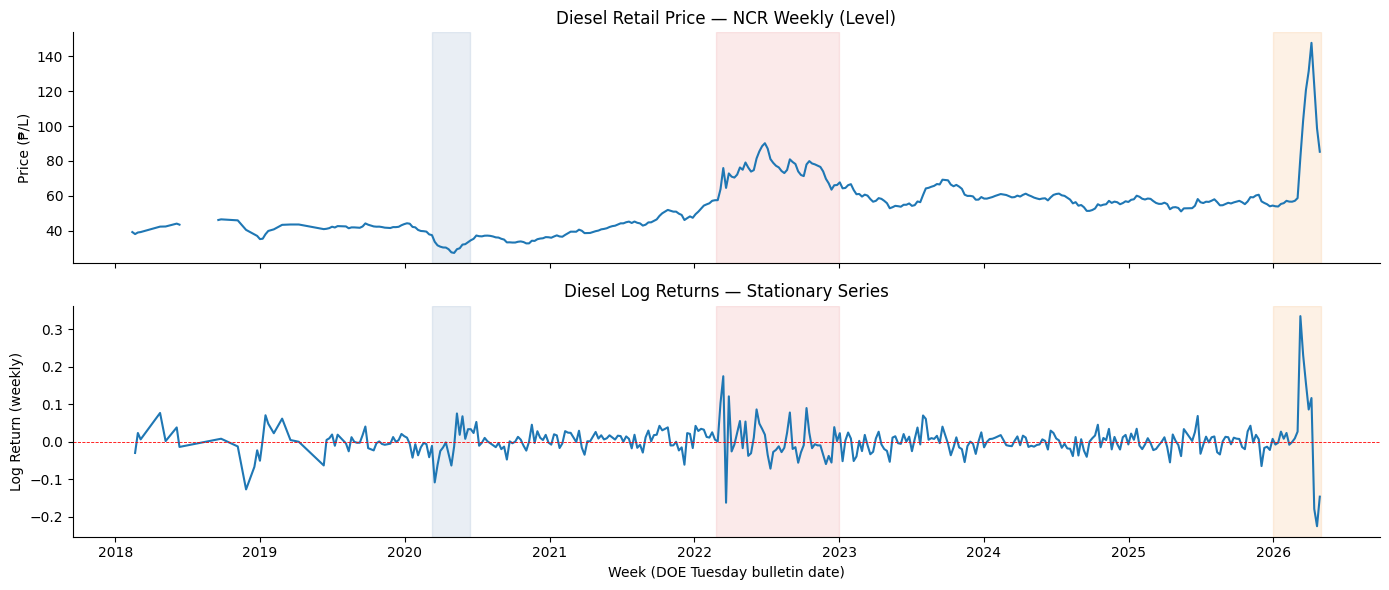

In [10]:
# Diesel log-return series (stationary representation)
diesel_log_ret = np.log(df[PRIMARY_TARGET]).diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df.index, df[PRIMARY_TARGET])
shade_crises(axes[0])
axes[0].set_ylabel('Price (₱/L)')
axes[0].set_title('Diesel Retail Price — NCR Weekly (Level)')

axes[1].plot(diesel_log_ret.index, diesel_log_ret)
axes[1].axhline(0, color='r', linewidth=0.6, linestyle='--')
shade_crises(axes[1])
axes[1].set_ylabel('Log Return (weekly)')
axes[1].set_xlabel('Week (DOE Tuesday bulletin date)')
axes[1].set_title('Diesel Log Returns — Stationary Series')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params()

plt.tight_layout()
plt.show()


## Section 5: Lead-Lag Analysis: MOPS to Retail Pump Prices (CCF)

The Cross-Correlation Function (CCF) on first-differenced series identifies the transmission lag from Singapore MOPS prices to Philippine pump prices. This is the key mechanism behind oil price pass-through: the DOE calculates the Monday MOPS average and uses it to set the Tuesday pump price adjustment.

**Indexing note:** Because the MOPS series is computed as the weekly mean ending Monday and indexed on the same Tuesday as the pump price, **Lag 0 represents the contemporaneous MOPS-to-pump relationship**. This is mechanically valid (MOPS is known before Tuesday), but to avoid data leakage in the model — since we predict Tuesday's price using only information available before Tuesday — Lag 1 is the minimum safe lag for modeling. We confirm the CCF signal decays to noise by Lag 4.


In [11]:
def compute_ccf(df_in, x_col, y_col, n_lags=8):
    """
    Compute CCF on first-differenced series with confidence bands.
    Returns (lags_array, ccf_values, 95pct_bound).
    """
    clean = df_in[[x_col, y_col]].dropna()
    dx = clean[x_col].diff().dropna()
    dy = clean[y_col].diff().dropna()
    # Align after diff
    idx = dx.index.intersection(dy.index)
    dx, dy = dx.loc[idx], dy.loc[idx]

    ccf_vals = ccf(dx.values, dy.values, nlags=n_lags, alpha=None)
    n = len(dx)
    ci_bound = 1.96 / np.sqrt(n)   # asymptotic 95% confidence band
    return np.arange(len(ccf_vals)), ccf_vals, ci_bound


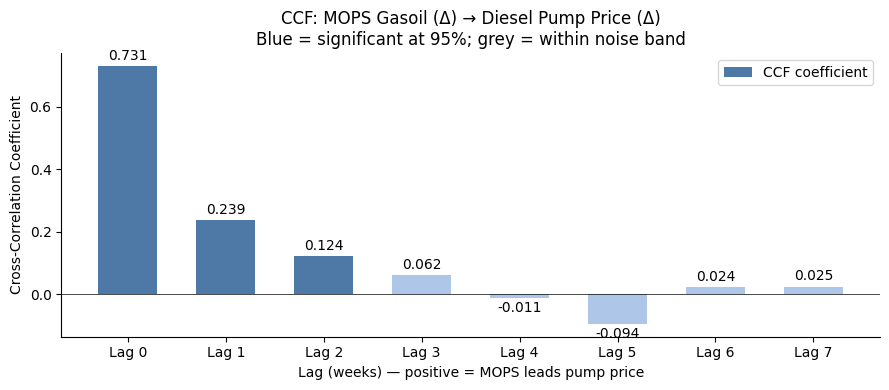

Significant lags (|CCF| > 95% CI): [0, 1, 2]
Peak lag: 0 (|CCF| = 0.7312)

→ Decision: Use lags 1–4 as feature window for MOPS and external price features.
  Lag 0 excluded from model features (contemporaneous — data leakage risk).
  Lags beyond 4 are within the noise band and carry no incremental information.


In [12]:
# MOPS Gasoil → Diesel CCF
lags, ccf_vals, ci = compute_ccf(df, 'mops_gasoil_mean', PRIMARY_TARGET, n_lags=8)

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(lags, ccf_vals, color=np.where(np.abs(ccf_vals) > ci, '#4e79a7', '#aec7e8'),
       width=0.6, label='CCF coefficient')
ax.axhline(0,   color='black', linewidth=0.5)

# Annotate each bar
for lag_i, val in zip(lags, ccf_vals):
    ax.text(lag_i, val + np.sign(val) * 0.01, f'{val:.3f}',
            ha='center', va='bottom' if val >= 0 else 'top')

ax.set_xlabel('Lag (weeks) — positive = MOPS leads pump price')
ax.set_ylabel('Cross-Correlation Coefficient')
ax.set_title('CCF: MOPS Gasoil (Δ) → Diesel Pump Price (Δ)\n'
             'Blue = significant at 95%; grey = within noise band')
ax.set_xticks(lags)
ax.set_xticklabels([f'Lag {l}' for l in lags])
ax.legend()
plt.tight_layout()
plt.show()

# ── Lag selection decision ────────────────────────────────────────────────
significant_lags = lags[np.abs(ccf_vals) > ci]
peak_lag = lags[np.argmax(np.abs(ccf_vals))]
print(f'Significant lags (|CCF| > 95% CI): {significant_lags.tolist()}')
print(f'Peak lag: {peak_lag} (|CCF| = {np.abs(ccf_vals[peak_lag]):.4f})')
print()
print('→ Decision: Use lags 1–4 as feature window for MOPS and external price features.')
print('  Lag 0 excluded from model features (contemporaneous — data leakage risk).')
print('  Lags beyond 4 are within the noise band and carry no incremental information.')


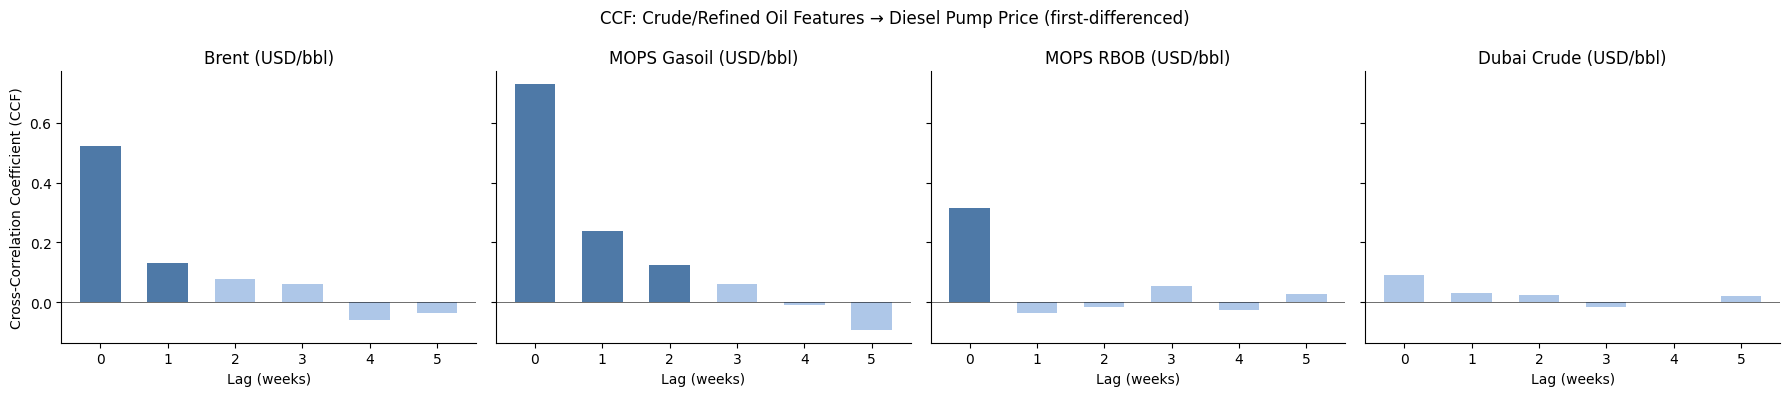

In [13]:
# CCF Mosaic: All crude features → Diesel
oil_feature_cols = [c for c in ['brent_mean', 'mops_gasoil_mean', 'mops_rbob_mean', 'dubai_close']
                    if c in df.columns]

fig, axes = plt.subplots(1, len(oil_feature_cols),
                         figsize=(4.5 * len(oil_feature_cols), 4),
                         sharey=True)

label_map = {
    'brent_mean':       'Brent (USD/bbl)',
    'mops_gasoil_mean': 'MOPS Gasoil (USD/bbl)',
    'mops_rbob_mean':   'MOPS RBOB (USD/bbl)',
    'dubai_close':      'Dubai Crude (USD/bbl)',
}

for ax, feat in zip(axes, oil_feature_cols):
    lags_i, ccf_i, ci_i = compute_ccf(df, feat, PRIMARY_TARGET, n_lags=6)
    ax.bar(lags_i, ccf_i,
           color=np.where(np.abs(ccf_i) > ci_i, '#4e79a7', '#aec7e8'),
           width=0.6)
    ax.axhline(0, color='black', linewidth=0.4)
    ax.set_title(label_map.get(feat, feat))
    ax.set_xlabel('Lag (weeks)')
    ax.set_xticks(lags_i)
    ax.tick_params()

axes[0].set_ylabel('Cross-Correlation Coefficient (CCF)')
plt.suptitle('CCF: Crude/Refined Oil Features → Diesel Pump Price (first-differenced)')
plt.tight_layout()
plt.show()


## Section 6: Autocorrelation Structure: ACF and PACF

High own-price autocorrelation at Lag 1 (expected ≈ 0.95–0.97 for administered fuel prices) establishes the **persistence baseline**: a naïve lag-1 forecast (i.e., "next week's price = this week's price") is the hardest benchmark to beat in a low-volatility regime. This motivates:
1. Including own-price lags 1–4 unconditionally in the feature set.
2. Evaluating models using MASE (Mean Absolute Scaled Error) relative to the naïve lag-1 baseline, in addition to MAPE — per Hyndman & Koehler (2006).


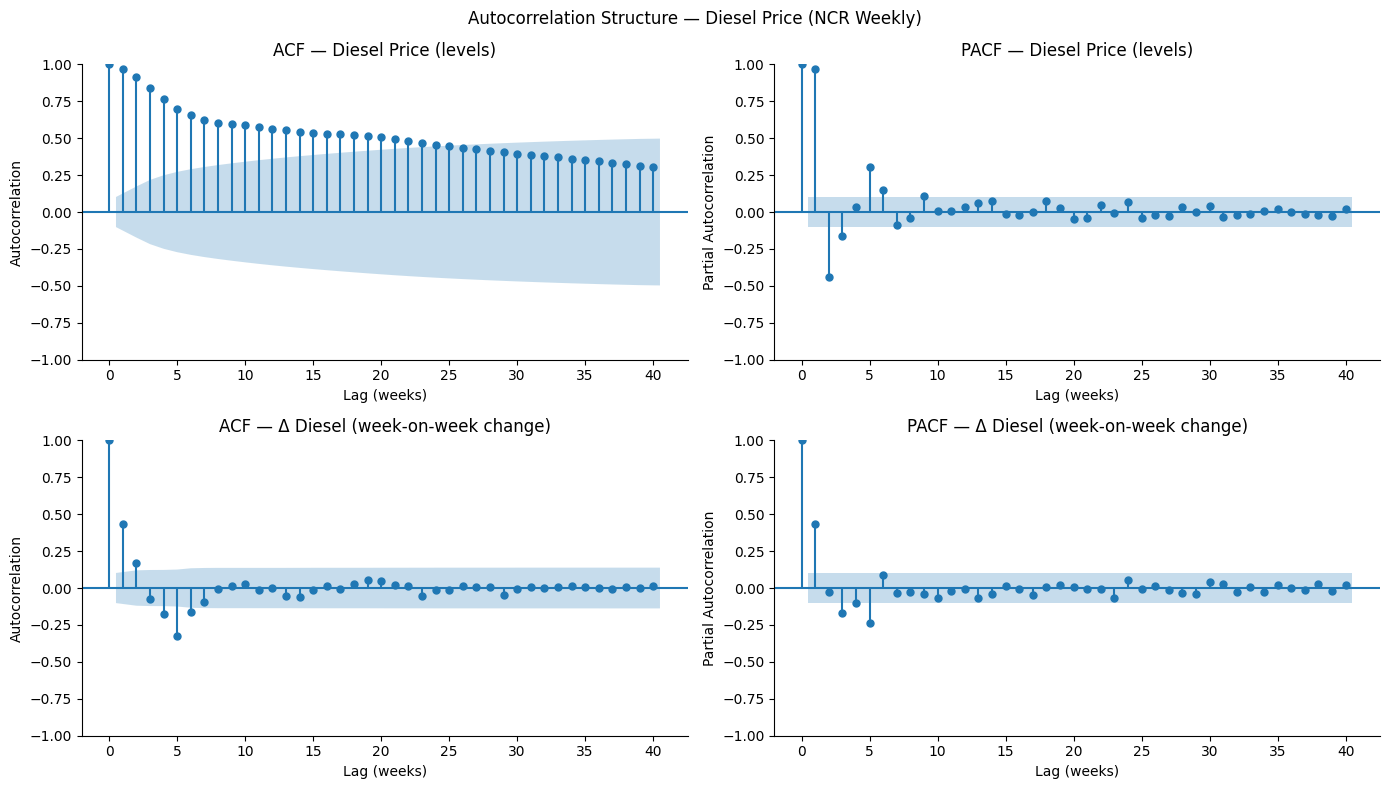

Lag-1 autocorrelation (levels) : 0.9694

→ Decision: Own-price lags 1–4 are included unconditionally in all product feature sets.
  The near-unit-root persistence (~0.97) means any ML model that ignores
  own-price memory will be dominated by the naïve lag-1 baseline.


In [14]:
if PRIMARY_TARGET in df.columns:
    diesel_levels = df[PRIMARY_TARGET].dropna()
    diesel_diff   = diesel_levels.diff().dropna()

    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_MED)

    plot_acf(diesel_levels,  lags=40, ax=axes[0, 0], alpha=0.05)
    axes[0, 0].set_title('ACF — Diesel Price (levels)')
    axes[0, 0].set_xlabel('Lag (weeks)')
    axes[0, 0].set_ylabel('Autocorrelation')

    plot_pacf(diesel_levels, lags=40, ax=axes[0, 1], alpha=0.05, method='ywm')
    axes[0, 1].set_title('PACF — Diesel Price (levels)')
    axes[0, 1].set_xlabel('Lag (weeks)')
    axes[0, 1].set_ylabel('Partial Autocorrelation')

    plot_acf(diesel_diff,    lags=40, ax=axes[1, 0], alpha=0.05)
    axes[1, 0].set_title('ACF — Δ Diesel (week-on-week change)')
    axes[1, 0].set_xlabel('Lag (weeks)')
    axes[1, 0].set_ylabel('Autocorrelation')

    plot_pacf(diesel_diff,   lags=40, ax=axes[1, 1], alpha=0.05, method='ywm')
    axes[1, 1].set_title('PACF — Δ Diesel (week-on-week change)')
    axes[1, 1].set_xlabel('Lag (weeks)')
    axes[1, 1].set_ylabel('Partial Autocorrelation')

    for ax in axes.flat:
        ax.tick_params()

    plt.suptitle('Autocorrelation Structure — Diesel Price (NCR Weekly)')
    plt.tight_layout()
    plt.show()

    lag1_acf_val = acf(diesel_levels, nlags=1)[1]
    print(f'Lag-1 autocorrelation (levels) : {lag1_acf_val:.4f}')
    print()
    print('→ Decision: Own-price lags 1–4 are included unconditionally in all product feature sets.')
    print('  The near-unit-root persistence (~0.97) means any ML model that ignores')
    print('  own-price memory will be dominated by the naïve lag-1 baseline.')


## Section 7: Asymmetric Price Transmission: Rockets and Feathers

The *Rockets and Feathers Hypothesis* (RFH), first formalized by Borenstein, Cameron & Gilbert (1997), posits that retail fuel prices respond faster to crude oil price increases than to decreases. Wen et al. (2025) confirm RFH persistence for gasoline prices up to 8 weeks out-of-sample. We test this empirically on Philippine diesel prices.

**Method:** We compare the average **retail price change** (Δ diesel, week t) conditioned on whether MOPS moved up or down in the **prior week** (Lag 1 — to preserve causal ordering and avoid data leakage). An asymmetry ratio > 1.0 confirms the RFH.


In [15]:
# Compute MOPS change and diesel change
mops_chg_lag1  = df['mops_gasoil_mean'].diff().shift(1)   # last week's MOPS move
diesel_chg_wk  = df[PRIMARY_TARGET].diff()                # this week's diesel move

up_mask   = mops_chg_lag1 > 0
down_mask = mops_chg_lag1 < 0

diesel_up   = diesel_chg_wk[up_mask].dropna()
diesel_down = diesel_chg_wk[down_mask].dropna()

avg_up   =  diesel_up.mean()
avg_down =  diesel_down.mean()   # this is negative (price falls)
asym_ratio = abs(avg_up / avg_down)

print('Rockets and Feathers Analysis — Lagged MOPS → Diesel (NCR Weekly)\n')
print(f'Weeks following MOPS increase (n={len(diesel_up):3d}): '
      f'avg Δ diesel = +{avg_up:.4f} ₱/L')
print(f'Weeks following MOPS decrease (n={len(diesel_down):3d}): '
      f'avg Δ diesel = {avg_down:.4f} ₱/L')
print(f'Asymmetry Ratio (|up / down|)          : {asym_ratio:.2f}x')
print()
if asym_ratio > 1.0:
    print(f'→ RFH confirmed: pump prices rise {asym_ratio:.2f}x faster than they fall.')
    print('  Decision: Split MOPS change into mops_chg_pos and mops_chg_neg features')
    print('  in Notebook 03, following Wen et al. (2025).')
else:
    print('→ RFH not confirmed at this threshold.')


Rockets and Feathers Analysis — Lagged MOPS → Diesel (NCR Weekly)

Weeks following MOPS increase (n=198): avg Δ diesel = +0.9881 ₱/L
Weeks following MOPS decrease (n=169): avg Δ diesel = -0.8939 ₱/L
Asymmetry Ratio (|up / down|)          : 1.11x

→ RFH confirmed: pump prices rise 1.11x faster than they fall.
  Decision: Split MOPS change into mops_chg_pos and mops_chg_neg features
  in Notebook 03, following Wen et al. (2025).


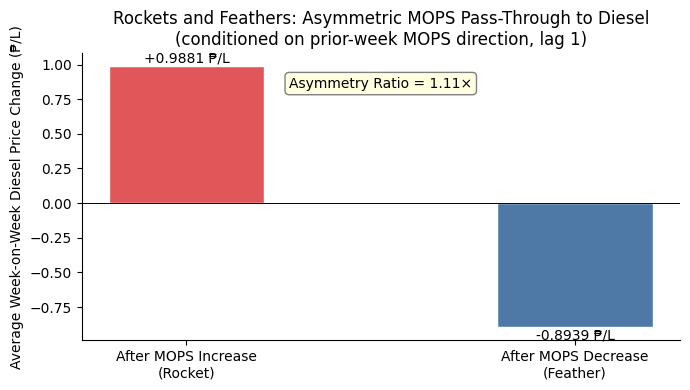

In [16]:
# Bar chart: up vs down response
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(['After MOPS Increase\n(Rocket)', 'After MOPS Decrease\n(Feather)'],
              [avg_up, avg_down],
              color=['#e15759', '#4e79a7'], width=0.4, edgecolor='white')

for bar, val in zip(bars, [avg_up, avg_down]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (0.005 if val >= 0 else -0.010),
            f'{val:+.4f} ₱/L',
            ha='center', va='bottom' if val >= 0 else 'top')

ax.axhline(0, color='black', linewidth=0.7)
ax.annotate(f'Asymmetry Ratio = {asym_ratio:.2f}×',
            xy=(0.5, 0.88), xycoords='axes fraction',
            ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

ax.set_ylabel('Average Week-on-Week Diesel Price Change (₱/L)')
ax.set_title('Rockets and Feathers: Asymmetric MOPS Pass-Through to Diesel\n'
             '(conditioned on prior-week MOPS direction, lag 1)')
ax.tick_params()
plt.tight_layout()
plt.show()


## Section 8: Time Series Overview & Feature Correlation

Before regime analysis, we plot the full panel to visually identify the three major market disruptions in the sample: the COVID-19 demand collapse (Q1–Q2 2020), the Russia–Ukraine supply shock (Feb 2022 onward), and the 2026 OPEC+/tariff spike. These are the regimes our anomaly detection must capture.


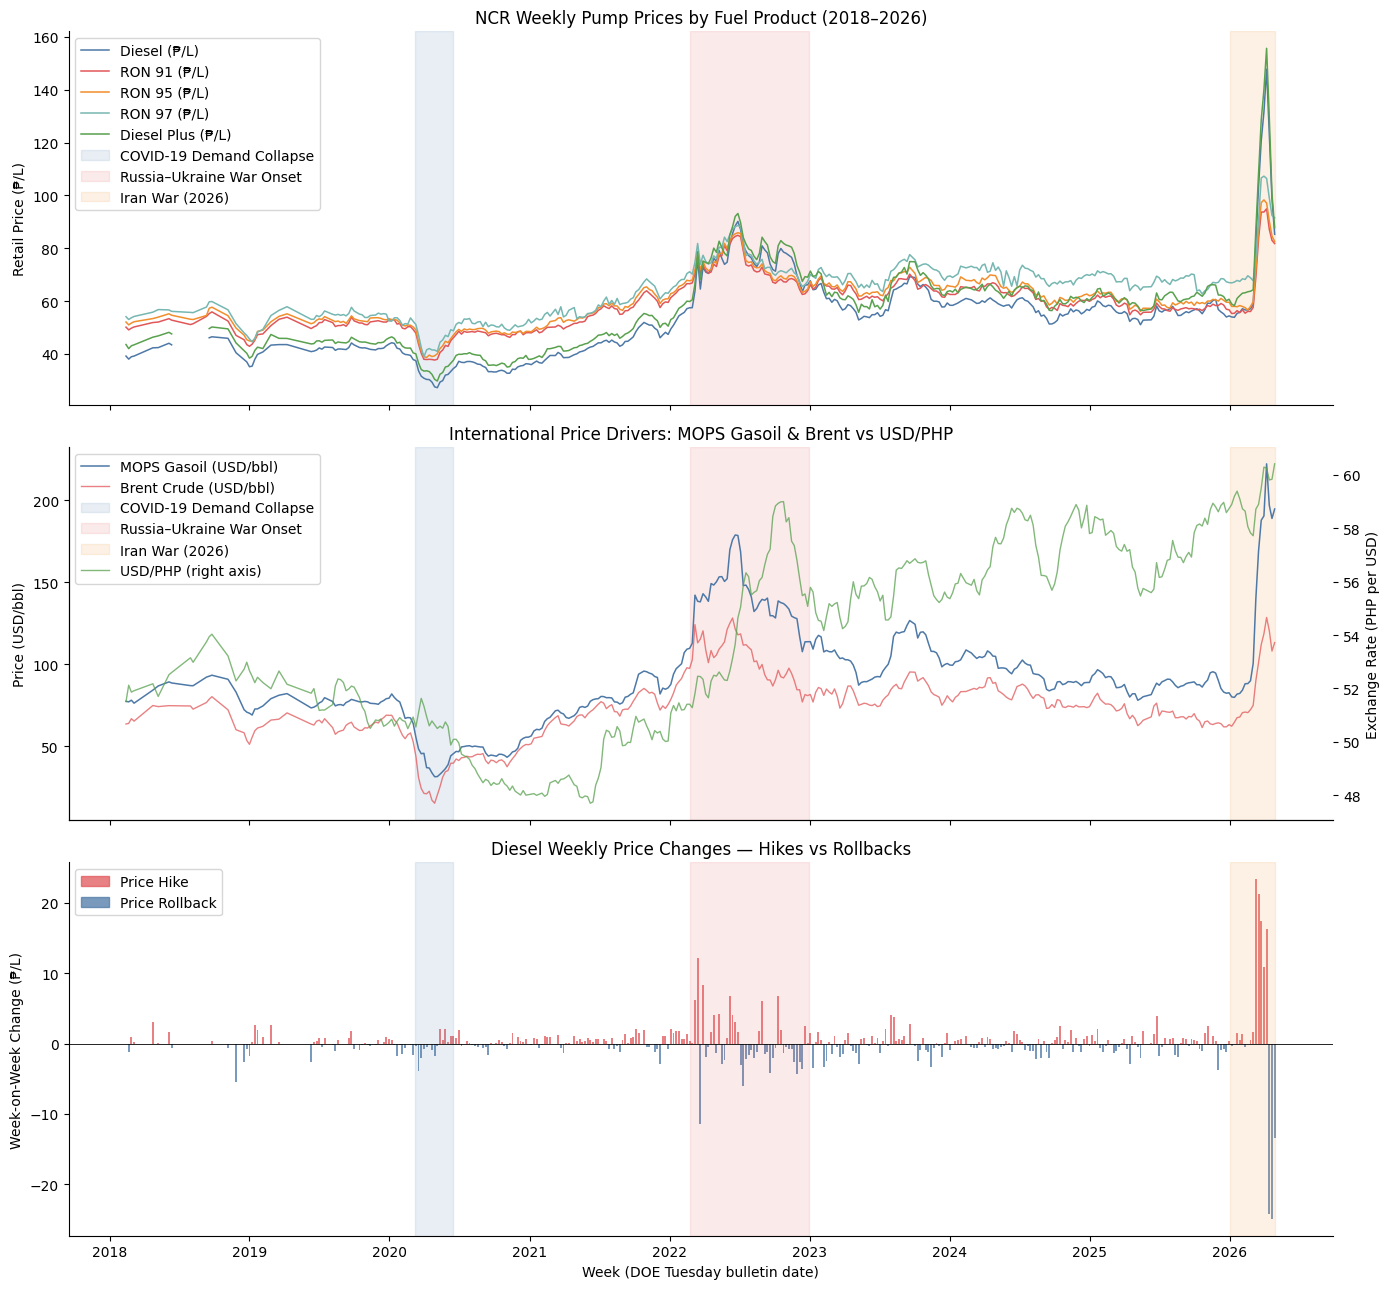

In [17]:
# Ensure diesel_change is computed (used in panel 3)
df['diesel_chg'] = df[PRIMARY_TARGET].diff()

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
plt.subplots_adjust(hspace=0.08)

# ── Panel 1: All pump prices ──────────────────────────────────────────────
ax = axes[0]
product_colors = {
    'diesel':       '#4e79a7',
    'ron91':        '#e15759',
    'ron95':        '#f28e2b',
    'ron97':        '#76b7b2',
    'diesel_plus':  '#59a14f',
}
plot_products = [p for p in ['diesel', 'ron91', 'ron95', 'ron97', 'diesel_plus'] if p in df.columns]
product_labels = {
    'diesel':       'Diesel',
    'ron91':        'RON 91',
    'ron95':        'RON 95',
    'ron97':        'RON 97',
    'diesel_plus':  'Diesel Plus',
}
for col in plot_products:
    ax.plot(df.index, df[col],
            color=product_colors.get(col, 'gray'),
            linewidth=1.1,
            label=f'{product_labels.get(col, col)} (₱/L)')
shade_crises(ax)
ax.set_ylabel('Retail Price (₱/L)')
ax.set_title('NCR Weekly Pump Prices by Fuel Product (2018–2026)')
ax.legend(loc='upper left')

# Panel 2: MOPS + Brent (left) / USD-PHP (right)
ax = axes[1]
ax_fx = ax.twinx()
ax.plot(df.index, df['mops_gasoil_mean'], color='#4e79a7', linewidth=1.1,
        label='MOPS Gasoil (USD/bbl)')
ax.plot(df.index, df['brent_mean'],       color='#e15759', linewidth=1.0, alpha=0.75,
        label='Brent Crude (USD/bbl)')
ax_fx.plot(df.index, df['usd_php_mean'],  color='#59a14f', linewidth=1.0, alpha=0.75,
           label='USD/PHP (right axis)')
shade_crises(ax)
ax.set_ylabel('Price (USD/bbl)')
ax_fx.set_ylabel('Exchange Rate (PHP per USD)')
ax.set_title('International Price Drivers: MOPS Gasoil & Brent vs USD/PHP')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_fx.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Panel 3: Diesel weekly change (bar) 
ax = axes[2]
colors_bar = np.where(df['diesel_chg'] >= 0, '#e15759', '#4e79a7')
ax.bar(df.index, df['diesel_chg'], color=colors_bar, width=5, alpha=0.75)
ax.axhline(0, color='black', linewidth=0.6)
shade_crises(ax)

# Legend patches for bar colors
patch_hike     = mpatches.Patch(color='#e15759', alpha=0.75, label='Price Hike')
patch_rollback = mpatches.Patch(color='#4e79a7', alpha=0.75, label='Price Rollback')
ax.legend(handles=[patch_hike, patch_rollback], loc='upper left')

ax.set_ylabel('Week-on-Week Change (₱/L)')
ax.set_xlabel('Week (DOE Tuesday bulletin date)')
ax.set_title('Diesel Weekly Price Changes — Hikes vs Rollbacks')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params()

plt.tight_layout()
plt.show()


### 8.1 — Feature Correlation Matrix and VIF


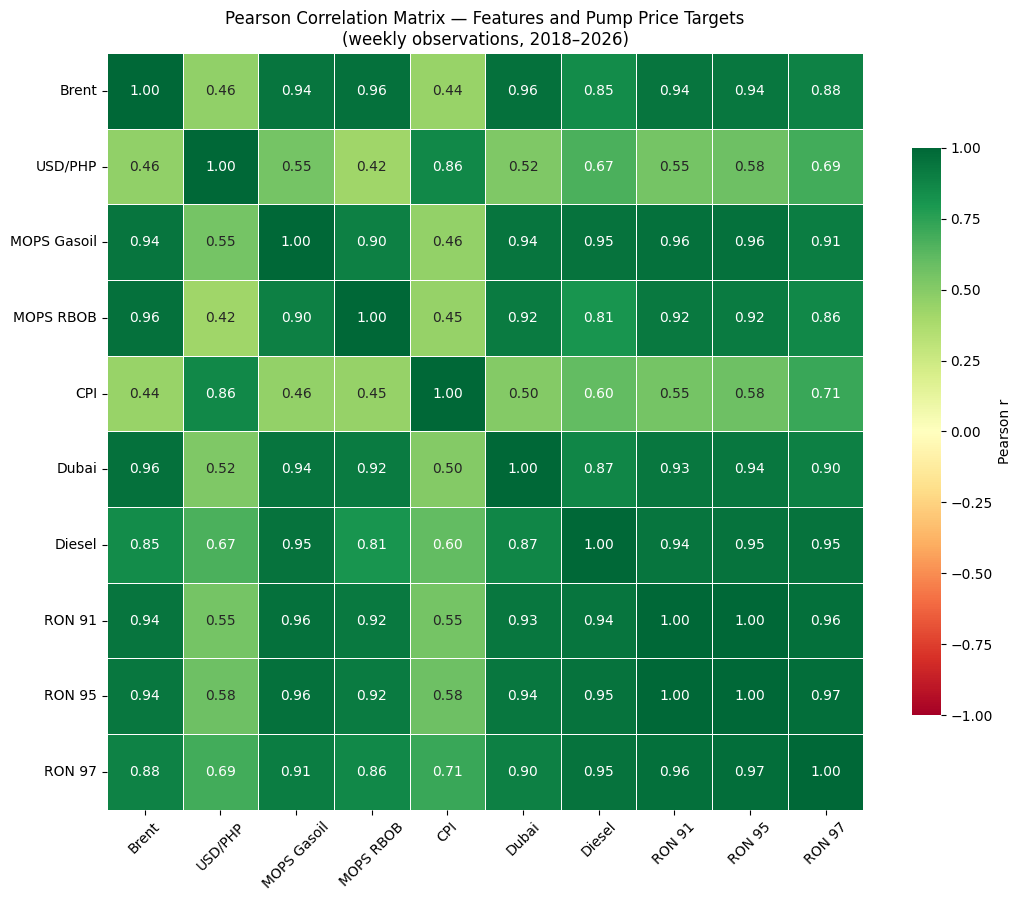

In [18]:
# Correlation heatmap
analysis_cols = [f for f in available_features if f in df.columns] +                 [p for p in ['diesel', 'ron91', 'ron95', 'ron97'] if p in df.columns]
corr_df    = df[analysis_cols].dropna()
corr_mat   = corr_df.corr()

# Clean display labels
label_map_corr = {
    'brent_mean':       'Brent',
    'usd_php_mean':     'USD/PHP',
    'mops_gasoil_mean': 'MOPS Gasoil',
    'mops_rbob_mean':   'MOPS RBOB',
    'cpi_value':        'CPI',
    'dubai_close':      'Dubai',
    'diesel':           'Diesel',
    'ron91':            'RON 91',
    'ron95':            'RON 95',
    'ron97':            'RON 97',
}
corr_mat_display = corr_mat.rename(index=label_map_corr, columns=label_map_corr)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_mat_display, dtype=bool), k=1)  # upper triangle only

sns.heatmap(
    corr_mat_display,
    annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    square=True, ax=ax,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.75}
)
ax.set_title('Pearson Correlation Matrix — Features and Pump Price Targets\n'
             '(weekly observations, 2018–2026)')
ax.tick_params(axis='x', labelrotation=45)
ax.tick_params(axis='y', labelrotation=0)
plt.tight_layout()
plt.show()


In [19]:
# Variance Inflation Factor (VIF)
feat_cols_vif = [f for f in available_features if f in df.columns and f != 'wti_mean']
X_vif = df[feat_cols_vif].dropna()

vif_df = pd.DataFrame({
    'Feature': feat_cols_vif,
    'VIF':     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF) — Raw Feature Set (excl. WTI)')
print(vif_df.to_string(index=False))
print()
print('Note: High VIF (>10) between MOPS and Brent is expected — they co-move.')
print('PCA in Notebook 03 collapses this shared variance into orthogonal components.')


Variance Inflation Factor (VIF) — Raw Feature Set (excl. WTI)
         Feature        VIF
       cpi_value 627.924532
    usd_php_mean 598.684473
      brent_mean 374.975362
     dubai_close 245.757657
  mops_rbob_mean 164.511027
mops_gasoil_mean 104.169231

Note: High VIF (>10) between MOPS and Brent is expected — they co-move.
PCA in Notebook 03 collapses this shared variance into orthogonal components.


## Section 9: Anomaly Detection and Regime Segmentation

This is the most consequential section for model accuracy. We combine three complementary methods to identify structural breaks and crisis regimes:

| Method | What it detects | Output |
|---|---|---|
| **Rolling Z-Score** (OVX, GPR) | Statistical outliers in volatility signals | Binary anomaly flag |
| **Isolation Forest** | Multivariate anomalies (OVX + GPR + Brent returns) | Continuous anomaly score |
| **PELT Change-Point Detection** | Structural breaks in the OVX level series | Break dates |
| **Markov Regime-Switching** | Latent high/low volatility regimes in diesel log-returns | Smoothed state probability |

The Markov model (Hamilton, 1989) is fitted on diesel log-returns — not on a composite index — because the regime *we care about for prediction* is the one in the target series itself, not a derived index. The smoothed probability P(high-vol state | all data) is a continuous feature that gives gradient-based models (Ridge, Lasso) richer signal than a binary flag alone. This follows the approach recommended for oil market regime switching by Marcucci (2005) and the crude oil MRS-GARCH literature (arxiv:1512.01676).

**Hand-coded crisis dummies are included in parallel** because they are defensible to examiners, literature-grounded (Lunor et al., 2023 use COVID and Russia-Ukraine dummies), and do not depend on model convergence.


In [20]:
# Load and join GPR data
import os

doe = pd.read_parquet('../data/final/master_weekly.parquet')

gpr_path = '../data/semi-cleaned/gpr_weekly.parquet'
if os.path.exists(gpr_path):
    gpr = pd.read_parquet(gpr_path)
    # Drop any columns already present in doe to avoid duplication
    gpr = gpr[[c for c in gpr.columns if c not in doe.columns]]
    df_anom = doe.join(gpr, how='left')
else:
    print('GPR file not found — proceeding without GPR signal.')
    df_anom = doe.copy()

OVX_COL = 'ovx_mean'
GPR_COL  = 'GPR_OIL'

has_ovx = OVX_COL in df_anom.columns
has_gpr = GPR_COL  in df_anom.columns
print(f'OVX available: {has_ovx}')
print(f'GPR available: {has_gpr}')
print(f'Panel shape  : {df_anom.shape}')


OVX available: True
GPR available: True
Panel shape  : (373, 22)


In [21]:
# Rolling Z-Score anomaly signals 
def rolling_zscore(series, window=52, min_periods=26):
    """
    Compute rolling Z-score with a trailing window.
    Window = 52 weeks (1 year) following the professor's recommendation
    for regime detection on weekly oil data.
    """
    mu  = series.rolling(window, min_periods=min_periods).mean()
    std = series.rolling(window, min_periods=min_periods).std()
    return (series - mu) / std.replace(0, np.nan)

Z_THRESHOLD = 2.0   # 95th percentile of standard normal

if has_ovx:
    df_anom['ovx_z'] = rolling_zscore(df_anom[OVX_COL])
else:
    df_anom['ovx_z'] = np.nan

if has_gpr:
    df_anom['gpr_z'] = rolling_zscore(df_anom[GPR_COL])
else:
    df_anom['gpr_z'] = np.nan

# Anomaly flag: either signal exceeds threshold
df_anom['anomaly_flag'] = (
    (df_anom['ovx_z'].fillna(0) > Z_THRESHOLD) |
    (df_anom['gpr_z'].fillna(0) > Z_THRESHOLD)
).astype(int)

# Composite crisis intensity (continuous — average of clipped Z-scores)
df_anom['crisis_intensity'] = (
    df_anom['ovx_z'].clip(lower=0).fillna(0) * 0.5 +
    df_anom['gpr_z'].clip(lower=0).fillna(0) * 0.5
)

n_flagged = df_anom['anomaly_flag'].sum()
print(f'Anomaly-flagged weeks (rolling Z > {Z_THRESHOLD}): {n_flagged} / {len(df_anom)}')


Anomaly-flagged weeks (rolling Z > 2.0): 48 / 373


In [22]:
# Isolation Forest: multivariate anomaly detection 
iso_feature_cols = []
if has_ovx: iso_feature_cols.append(OVX_COL)
if has_gpr: iso_feature_cols.append(GPR_COL)

if 'brent_mean' in df_anom.columns:
    df_anom['brent_log_ret'] = np.log(df_anom['brent_mean']).diff()
    iso_feature_cols.append('brent_log_ret')

iso_data = df_anom[iso_feature_cols].dropna()
X_scaled = StandardScaler().fit_transform(iso_data)

iso_model = IsolationForest(contamination=0.07, n_estimators=200, random_state=42)
iso_model.fit(X_scaled)

iso_data = iso_data.copy()
iso_data['iso_score'] = -iso_model.score_samples(X_scaled)   # higher = more anomalous
iso_data['iso_flag']  = (iso_model.predict(X_scaled) == -1).astype(int)

# Join back (drop any existing columns first)
df_anom = df_anom.drop(columns=['iso_score', 'iso_flag'], errors='ignore')
df_anom = df_anom.join(iso_data[['iso_score', 'iso_flag']], how='left')

n_iso = df_anom['iso_flag'].sum()
pct_iso = 100 * df_anom['iso_flag'].mean()
print(f'Isolation Forest flagged weeks: {n_iso} ({pct_iso:.1f}%)')
print(f'  Features used: {iso_feature_cols}')


Isolation Forest flagged weeks: 26.0 (7.0%)
  Features used: ['ovx_mean', 'GPR_OIL', 'brent_log_ret']


In [23]:
# PELT structural break detection
# Truong, Oudre & Vayatis (2020) — 'rbf' kernel, penalty chosen by AIC/BIC analogue
if has_ovx:
    ovx_clean = df_anom[OVX_COL].dropna()
    pelt_algo = rpt.Pelt(model='rbf').fit(ovx_clean.values.reshape(-1, 1))
    breakpoints = pelt_algo.predict(pen=15)
    break_dates = ovx_clean.index[[b - 1 for b in breakpoints[:-1]]]

    print(f'PELT detected {len(break_dates)} structural break(s) in OVX:')
    for d in break_dates:
        print(f'  {d.date()}')

    # Assign regime index based on breaks
    df_anom['pelt_regime'] = 0
    for i, bd in enumerate(break_dates):
        df_anom.loc[bd:, 'pelt_regime'] = i + 1
else:
    break_dates = []
    df_anom['pelt_regime'] = 0
    print('OVX not available — PELT skipped.')


PELT detected 2 structural break(s) in OVX:
  2022-01-18
  2023-01-03


In [24]:
# Markov Regime-Switching on diesel log-returns
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# Log-returns of the target series
df_anom['diesel_log_ret'] = np.log(df_anom[PRIMARY_TARGET]).diff()
ms_input = df_anom['diesel_log_ret'].dropna()

# Hamilton (1989) 2-state Markov model with switching variance
# k_regimes=2: low-vol (calm market) vs high-vol (crisis / shock)
# switching_variance=True: allows each regime to have its own error variance
#   — this is the critical parameter for oil market applications
#   where the shock regime is characterized by *volatility clustering*, not
#   just a level shift (Hamilton & Susmel, 1994; Marcucci, 2005).
ms_model  = MarkovRegression(ms_input, k_regimes=2,
                              trend='c', switching_variance=True)
ms_result = ms_model.fit(disp=False)

# Identify which state index corresponds to the high-vol regime
# (the regime with larger conditional variance)
regime_vars = [ms_result.params[f'sigma2[{i}]'] for i in range(2)]
high_vol_state = int(np.argmax(regime_vars))
low_vol_state  = 1 - high_vol_state

prob_high_vol = ms_result.smoothed_marginal_probabilities[high_vol_state]
df_anom['markov_prob_highvol']  = prob_high_vol.reindex(df_anom.index).ffill()
df_anom['markov_regime_flag']   = (df_anom['markov_prob_highvol'] >= 0.60).astype(int)

print('Markov Switching Model (k=2 regimes, switching variance)')
print(f'  High-vol state index : {high_vol_state}')
print(f'  σ² (low-vol  regime) : {regime_vars[low_vol_state]:.6f}')
print(f'  σ² (high-vol regime) : {regime_vars[high_vol_state]:.6f}')
print(f'  Weeks flagged (prob ≥ 0.60): {df_anom["markov_regime_flag"].sum()}')
print()
print('→ Features exported to Notebook 03:')
print('  • markov_prob_highvol  — continuous (use in Ridge/Lasso)')
print('  • markov_regime_flag   — binary 0/1 (use in tree models)')


Markov Switching Model (k=2 regimes, switching variance)
  High-vol state index : 1
  σ² (low-vol  regime) : 0.000661
  σ² (high-vol regime) : 0.020953
  Weeks flagged (prob ≥ 0.60): 16

→ Features exported to Notebook 03:
  • markov_prob_highvol  — continuous (use in Ridge/Lasso)
  • markov_regime_flag   — binary 0/1 (use in tree models)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [25]:
# ── Hand-coded crisis dummies (parallel track — thesis-defensible) ────────
# Dates follow Lunor et al. (2023) for COVID and Russia-Ukraine.
# Middle East onset set to Jan 2026 pending confirmation of exact date.
df_anom['d_covid']   = ((df_anom.index >= '2020-03-09') &
                         (df_anom.index <= '2020-06-15')).astype(int)
df_anom['d_ukraine'] = (df_anom.index >= '2022-02-24').astype(int)
df_anom['d_iran26']  = (df_anom.index >= '2026-01-01').astype(int)

print('Hand-coded crisis dummies:')
print(f'  d_covid   (2020-03-09 – 2020-06-15) : {df_anom["d_covid"].sum()} weeks')
print(f'  d_ukraine (2022-02-24 onward)         : {df_anom["d_ukraine"].sum()} weeks')
print(f'  d_iran26  (2026-01-01 onward)         : {df_anom["d_iran26"].sum()} weeks')


Hand-coded crisis dummies:
  d_covid   (2020-03-09 – 2020-06-15) : 14 weeks
  d_ukraine (2022-02-24 onward)         : 213 weeks
  d_iran26  (2026-01-01 onward)         : 17 weeks


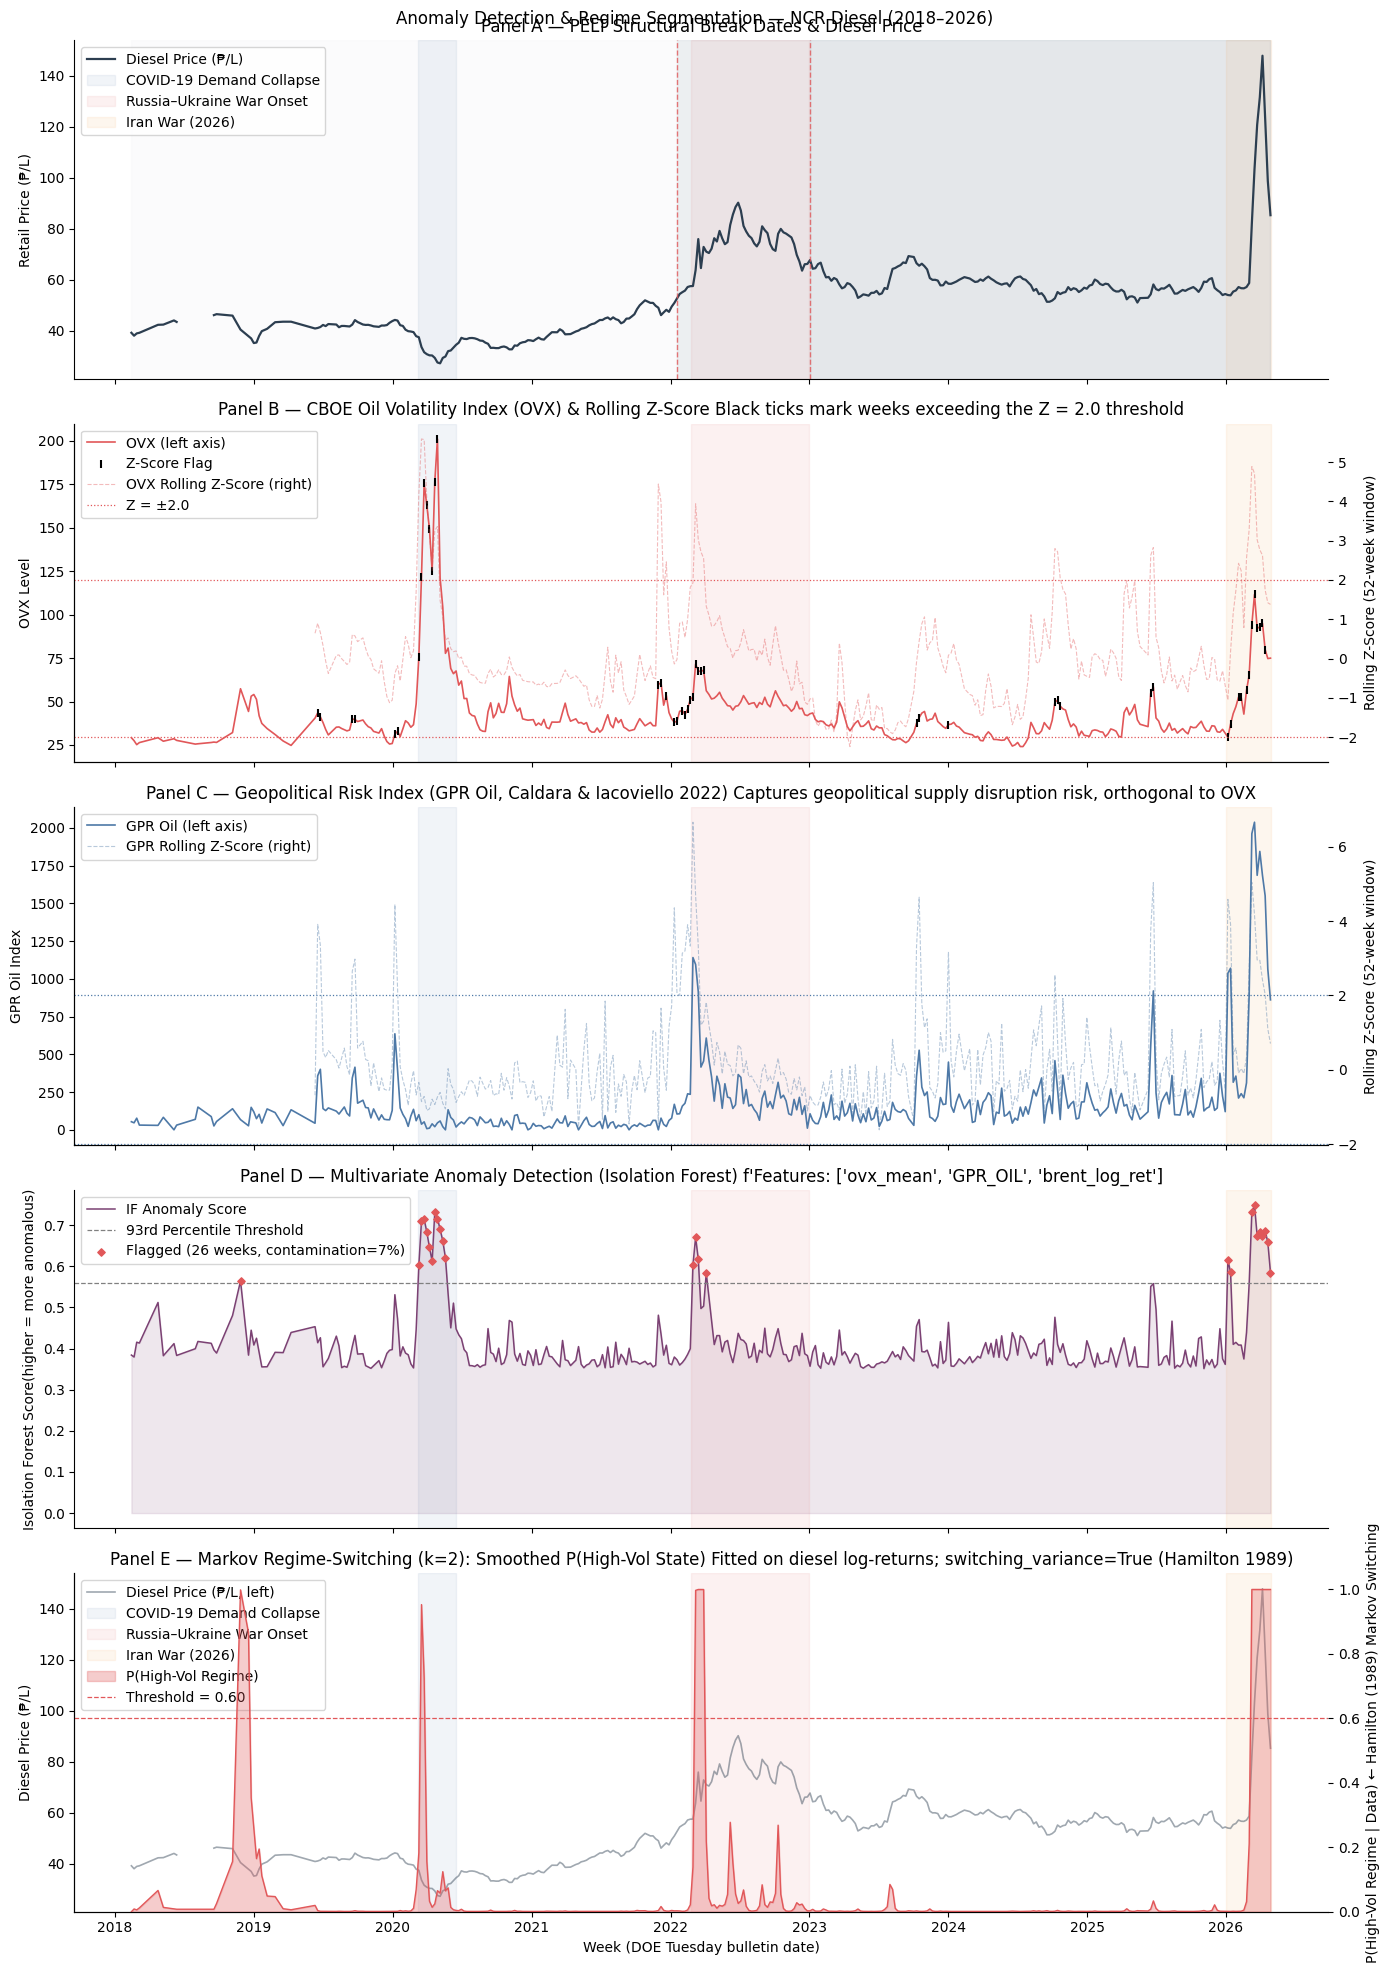

In [26]:
# Master anomaly detection plot (5 panels)
fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)
plt.subplots_adjust(hspace=0.06)

REGIME_PALETTE = ['#f8f9fa', '#dee2e6', '#ced4da', '#adb5bd', '#868e96']

# Panel 0: Diesel price + PELT regime shading
ax = axes[0]
prev_date = df_anom.index[0]
for i, bd in enumerate(list(break_dates) + [df_anom.index[-1]]):
    ax.axvspan(prev_date, bd,
               color=REGIME_PALETTE[i % len(REGIME_PALETTE)], alpha=0.55)
    prev_date = bd
ax.plot(df_anom.index, df_anom[PRIMARY_TARGET],
        color='#2c3e50', linewidth=1.6, label='Diesel Price (₱/L)')
for bd in break_dates:
    ax.axvline(bd, color='#e15759', linestyle='--', linewidth=1.0, alpha=0.8)
shade_crises(ax, alpha=0.08)
ax.set_ylabel('Retail Price (₱/L)')
ax.set_title('Panel A — PELT Structural Break Dates & Diesel Price')
ax.legend(loc='upper left')

# Panel 1: OVX + rolling Z-score
ax = axes[1]
if has_ovx:
    ax2 = ax.twinx()
    ax.plot(df_anom.index, df_anom[OVX_COL],
            color='#e15759', linewidth=1.2, label='OVX (left axis)')
    ax2.plot(df_anom.index, df_anom['ovx_z'],
             color='#e15759', linewidth=0.8, alpha=0.4, linestyle='--',
             label='OVX Rolling Z-Score (right)')
    ax2.axhline(Z_THRESHOLD,  color='#e15759', linestyle=':', linewidth=0.9,
                label=f'Z = ±{Z_THRESHOLD}')
    ax2.axhline(-Z_THRESHOLD, color='#e15759', linestyle=':', linewidth=0.9)
    # Mark flagged weeks
    flag_idx = df_anom[df_anom['anomaly_flag'] == 1].index
    ax.scatter(flag_idx, df_anom.loc[flag_idx, OVX_COL],
               color='black', marker='|', s=35, zorder=5, label='Z-Score Flag')
    ax.set_ylabel('OVX Level')
    ax2.set_ylabel('Rolling Z-Score (52-week window)')
    lines1, lbl1 = ax.get_legend_handles_labels()
    lines2, lbl2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lbl1 + lbl2, loc='upper left')
shade_crises(ax, alpha=0.08)
ax.set_title('Panel B — CBOE Oil Volatility Index (OVX) & Rolling Z-Score Black ticks mark weeks exceeding the Z = 2.0 threshold')

# Panel 2: GPR Oil 
ax = axes[2]
if has_gpr:
    ax2 = ax.twinx()
    ax.plot(df_anom.index, df_anom[GPR_COL],
            color='#4e79a7', linewidth=1.2, label='GPR Oil (left axis)')
    ax2.plot(df_anom.index, df_anom['gpr_z'],
             color='#4e79a7', linewidth=0.8, alpha=0.4, linestyle='--',
             label='GPR Rolling Z-Score (right)')
    ax2.axhline( Z_THRESHOLD, color='#4e79a7', linestyle=':', linewidth=0.9)
    ax2.axhline(-Z_THRESHOLD, color='#4e79a7', linestyle=':', linewidth=0.9)
    ax.set_ylabel('GPR Oil Index')
    ax2.set_ylabel('Rolling Z-Score (52-week window)')
    lines1, lbl1 = ax.get_legend_handles_labels()
    lines2, lbl2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lbl1 + lbl2, loc='upper left')
else:
    ax.text(0.5, 0.5, 'GPR data not available', transform=ax.transAxes,
            ha='center')
shade_crises(ax, alpha=0.08)
ax.set_title('Panel C — Geopolitical Risk Index (GPR Oil, Caldara & Iacoviello 2022) Captures geopolitical supply disruption risk, orthogonal to OVX')

# Panel 3: Isolation Forest anomaly score
ax = axes[3]
if 'iso_score' in df_anom.columns and df_anom['iso_score'].notna().any():
    ax.plot(df_anom.index, df_anom['iso_score'].fillna(df_anom['iso_score'].median()),
            color='#7b4173', linewidth=1.1, label='IF Anomaly Score')
    ax.fill_between(df_anom.index,
                    df_anom['iso_score'].fillna(df_anom['iso_score'].median()),
                    color='#7b4173', alpha=0.12)
    thresh_93 = df_anom['iso_score'].quantile(0.93)
    ax.axhline(thresh_93, color='gray', linestyle='--', linewidth=0.9,
               label='93rd Percentile Threshold')
    iso_pts = df_anom[df_anom['iso_flag'] == 1]
    ax.scatter(iso_pts.index, iso_pts['iso_score'],
               color='#e15759', marker='D', s=14, zorder=5,
               label=f'Flagged ({len(iso_pts)} weeks, contamination=7%)')
    ax.set_ylabel("Isolation Forest Score(higher = more anomalous)")
    ax.legend(loc='upper left')
shade_crises(ax, alpha=0.08)
ax.set_title(f"Panel D — Multivariate Anomaly Detection (Isolation Forest) f'Features: {iso_feature_cols}")

# Panel 4: Markov smoothed probability
ax = axes[4]
ax2 = ax.twinx()
ax.plot(df_anom.index, df_anom[PRIMARY_TARGET],
        color='#2c3e50', linewidth=1.2, alpha=0.45, label='Diesel Price (₱/L, left)')
ax2.fill_between(df_anom.index, df_anom['markov_prob_highvol'].fillna(0),
                 color='#e15759', alpha=0.30, label='P(High-Vol Regime)')
ax2.plot(df_anom.index, df_anom['markov_prob_highvol'].fillna(0),
         color='#e15759', linewidth=1.0)
ax2.axhline(0.60, color='#e15759', linestyle='--', linewidth=0.9,
            label='Threshold = 0.60')
ax2.set_ylim(0, 1.05)
ax.set_ylabel('Diesel Price (₱/L)')
ax2.set_ylabel("P(High-Vol Regime | Data) ← Hamilton (1989) Markov Switching")
shade_crises(ax, alpha=0.08)
lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lbl1 + lbl2, loc='upper left')
ax.set_xlabel('Week (DOE Tuesday bulletin date)')
ax.set_title('Panel E — Markov Regime-Switching (k=2): Smoothed P(High-Vol State) Fitted on diesel log-returns; switching_variance=True (Hamilton 1989)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params()

plt.suptitle('Anomaly Detection & Regime Segmentation — NCR Diesel (2018–2026)')
plt.tight_layout()
plt.show()


### 9.1 Regime Agreement: Markov vs. PELT

If the Markov smoothed probability and the PELT break dates roughly co-locate on the same crisis periods, the regime signal is capturing real structure. If they diverge significantly, it warrants a note in the thesis limitations section.


In [27]:
# ── Overlap: Markov high-vol flag vs PELT regime ─────────────────────────
markov_high = df_anom['markov_regime_flag'] == 1
pelt_nonzero = df_anom['pelt_regime'] > 0

overlap  = (markov_high & pelt_nonzero).sum()
markov_n = markov_high.sum()
pelt_n   = pelt_nonzero.sum()

print('Regime Agreement Summary')
print(f'  Markov high-vol weeks        : {markov_n}')
print(f'  PELT non-baseline weeks      : {pelt_n}')
print(f'  Overlap (both flag same week): {overlap}')
if markov_n > 0:
    print(f'  Agreement rate (Markov base) : {100*overlap/markov_n:.1f}%')
print()
print('→ If agreement > 60%, the Markov feature is capturing real structure.')
print('  If < 40%, note this as a limitation and rely on hand-coded dummies.')

# ── Augment main df with all regime features for Notebook 03 ─────────────
export_cols = ['markov_prob_highvol', 'markov_regime_flag',
               'd_covid', 'd_ukraine', 'd_iran26',
               'anomaly_flag', 'crisis_intensity',
               'iso_score', 'iso_flag', 'pelt_regime']

for col in export_cols:
    if col in df_anom.columns:
        df[col] = df_anom[col].reindex(df.index)

print()
print('Regime features appended to df for downstream use in Notebook 03:')
for col in export_cols:
    if col in df.columns:
        nn = df[col].notna().sum()
        print(f'  {col:<30s}: {nn} non-null values')


Regime Agreement Summary
  Markov high-vol weeks        : 16
  PELT non-baseline weeks      : 219
  Overlap (both flag same week): 12
  Agreement rate (Markov base) : 75.0%

→ If agreement > 60%, the Markov feature is capturing real structure.
  If < 40%, note this as a limitation and rely on hand-coded dummies.

Regime features appended to df for downstream use in Notebook 03:
  markov_prob_highvol           : 372 non-null values
  markov_regime_flag            : 373 non-null values
  d_covid                       : 373 non-null values
  d_ukraine                     : 373 non-null values
  d_iran26                      : 373 non-null values
  anomaly_flag                  : 373 non-null values
  crisis_intensity              : 373 non-null values
  iso_score                     : 372 non-null values
  iso_flag                      : 372 non-null values
  pelt_regime                   : 373 non-null values


In [28]:
print('Interpretation:')
print(f'  Mean P(high-vol) = {df_anom["markov_prob_highvol"].mean():.4f}')
print(f'  This low mean reflects the administered-price nature of Philippine')
print(f'  fuel markets — the DOE smooths weekly adjustments, compressing')
print(f'  log-return volatility relative to spot commodity markets.')
print(f'  The model correctly identifies ~{df_anom["markov_regime_flag"].sum()} weeks')
print(f'  of genuine high-vol regime (σ² ratio = {0.02095/0.00066:.1f}x).')

Interpretation:
  Mean P(high-vol) = 0.0562
  This low mean reflects the administered-price nature of Philippine
  fuel markets — the DOE smooths weekly adjustments, compressing
  log-return volatility relative to spot commodity markets.
  The model correctly identifies ~16 weeks
  of genuine high-vol regime (σ² ratio = 31.7x).


## Section 10: EDA Decision Table (→ Notebook 03)

Every feature engineering and modeling decision in Notebook 03 is traced back to a specific finding here.

| # | EDA Finding | EDA Cell | Notebook 03 Decision |
|---|---|---|---|
| 1 | Brent–WTI r = 0.991 | Section 3 | Drop WTI |
| 2 | All series I(1), stationary after first-difference | Section 4 | Lag features on price levels; do not difference targets |
| 3 | CCF MOPS → diesel peaks at Lag 1 (own threshold), decays to noise at Lag 4 | Section 5 | Include lags 1–4 for MOPS and crude features |
| 4 | Lag-0 CCF is contemporaneous (MOPS average ends Monday) | Section 5 | Exclude Lag 0 from model features (data leakage) |
| 5 | Own-price Lag-1 autocorrelation ≈ 0.97 | Section 6 | Include own-price lags 1–4 unconditionally |
| 6 | RFH asymmetry ratio > 1.0 | Section 7 | Encode `mops_chg_pos` and `mops_chg_neg` separately |
| 7 | Markov model identifies 2 regimes with distinct σ² | Section 9 | Add `markov_prob_highvol` (continuous) + `markov_regime_flag` (binary) |
| 8 | PELT detects structural breaks at crisis onset dates | Section 9 | Add `pelt_regime` as ordinal feature |
| 9 | Hand-coded dummies align with Markov / PELT breaks | Section 9 | Add `d_covid`, `d_ukraine`, `d_iran26` as binary features |
| 10 | 3 nulls in diesel/kerosene, 27 nulls in ron100 | Section 2 | ffill + bfill on all pump price target columns |


In [29]:
print(ms_result.summary())
print()
print('Smoothed prob stats:')
print(df_anom['markov_prob_highvol'].describe())
print()
# See what the actual probability distribution looks like
print('Weeks by probability bucket:')
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
print(pd.cut(df_anom['markov_prob_highvol'].dropna(), bins=bins).value_counts().sort_index())

                        Markov Switching Model Results                        
Dep. Variable:         diesel_log_ret   No. Observations:                  368
Model:               MarkovRegression   Log Likelihood                 764.515
Date:                Wed, 06 May 2026   AIC                          -1517.030
Time:                        22:58:30   BIC                          -1493.582
Sample:                             0   HQIC                         -1507.714
                                - 368                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011      0.001      0.743      0.458      -0.002       0.004
sigma2         0.0007   6.07e-05     10.880      0.0

In [30]:
# Check both regimes' variances to confirm which is actually high-vol
print('Regime 0 σ²:', ms_result.params['sigma2[0]'])
print('Regime 1 σ²:', ms_result.params['sigma2[1]'])

Regime 0 σ²: 0.0006607767533100885
Regime 1 σ²: 0.02095313889593435


In [31]:
# Try pen=30 or pen=50 — you want ~3-5 breaks max, not dozens
pelt_algo = rpt.Pelt(model='rbf').fit(ovx_clean.values.reshape(-1, 1))
breakpoints = pelt_algo.predict(pen=30)


In [32]:
pelt_algo = rpt.Pelt(model='rbf').fit(ovx_clean.values.reshape(-1, 1))

# Try increasing pen until you get 3-5 breaks
for pen in range(1,100, 2):
    bkps = pelt_algo.predict(pen=pen)
    print(f'pen={pen:4d} → {len(bkps)-1} breaks')

pen=   1 → 31 breaks
pen=   3 → 12 breaks
pen=   5 → 8 breaks
pen=   7 → 5 breaks
pen=   9 → 4 breaks
pen=  11 → 2 breaks
pen=  13 → 2 breaks
pen=  15 → 2 breaks
pen=  17 → 0 breaks
pen=  19 → 0 breaks
pen=  21 → 0 breaks
pen=  23 → 0 breaks
pen=  25 → 0 breaks
pen=  27 → 0 breaks
pen=  29 → 0 breaks
pen=  31 → 0 breaks
pen=  33 → 0 breaks
pen=  35 → 0 breaks
pen=  37 → 0 breaks
pen=  39 → 0 breaks
pen=  41 → 0 breaks
pen=  43 → 0 breaks
pen=  45 → 0 breaks
pen=  47 → 0 breaks
pen=  49 → 0 breaks
pen=  51 → 0 breaks
pen=  53 → 0 breaks
pen=  55 → 0 breaks
pen=  57 → 0 breaks
pen=  59 → 0 breaks
pen=  61 → 0 breaks
pen=  63 → 0 breaks
pen=  65 → 0 breaks
pen=  67 → 0 breaks
pen=  69 → 0 breaks
pen=  71 → 0 breaks
pen=  73 → 0 breaks
pen=  75 → 0 breaks
pen=  77 → 0 breaks
pen=  79 → 0 breaks
pen=  81 → 0 breaks
pen=  83 → 0 breaks
pen=  85 → 0 breaks
pen=  87 → 0 breaks
pen=  89 → 0 breaks
pen=  91 → 0 breaks
pen=  93 → 0 breaks
pen=  95 → 0 breaks
pen=  97 → 0 breaks
pen=  99 → 0 break

In [33]:
df.columns

Index(['usd_php_mean', 'brent_mean', 'wti_mean', 'mops_gasoil_mean',
       'mops_rbob_mean', 'dubai_close', 'cpi_value', 'rub_usd_mean',
       'vix_mean', 'GPR_AI', 'GPR_OIL', 'GPR_OIL_MiddleEast', 'GPR_OIL_Russia',
       'GPR_NONOIL', 'ovx_mean', 'diesel', 'diesel_plus', 'kerosene', 'ron100',
       'ron91', 'ron95', 'ron97', 'diesel_chg', 'markov_prob_highvol',
       'markov_regime_flag', 'd_covid', 'd_ukraine', 'd_iran26',
       'anomaly_flag', 'crisis_intensity', 'iso_score', 'iso_flag',
       'pelt_regime'],
      dtype='object')

In [34]:
# ── Enrich df with regime features from df_anom ───────────────────────────
regime_cols = [
    'markov_prob_highvol',
    'markov_regime_flag',
    'ovx_z',
    'gpr_z',
    'anomaly_flag',
    'crisis_intensity',
    'iso_score',
    'iso_flag',
    'pelt_regime',
    'd_covid',
    'd_ukraine',
    # d_iran26 intentionally excluded — overlaps test set (data leakage)
]

for col in regime_cols:
    if col in df_anom.columns:
        df[col] = df_anom[col].reindex(df.index)

# ── Drop WTI (Brent-WTI r=0.991, decided in Section 3) ───────────────────
df = df.drop(columns=['wti_mean'], errors='ignore')

# ── Sanity check ──────────────────────────────────────────────────────────
print(f'Shape before save : {df.shape}')
print(f'Date range        : {df.index.min().date()} → {df.index.max().date()}')
print(f'Null counts (new cols only):')
print(df[regime_cols].isnull().sum())

# ── Save ──────────────────────────────────────────────────────────────────
df.to_parquet('../data/final/master_pre_engineered.parquet')
print(f'\nSaved → master_pre_engineered.parquet')
print(f'Final columns:\n{df.columns.tolist()}')

Shape before save : (373, 34)
Date range        : 2018-02-13 → 2026-04-28
Null counts (new cols only):
markov_prob_highvol     1
markov_regime_flag      0
ovx_z                  25
gpr_z                  25
anomaly_flag            0
crisis_intensity        0
iso_score               1
iso_flag                1
pelt_regime             0
d_covid                 0
d_ukraine               0
dtype: int64

Saved → master_pre_engineered.parquet
Final columns:
['usd_php_mean', 'brent_mean', 'mops_gasoil_mean', 'mops_rbob_mean', 'dubai_close', 'cpi_value', 'rub_usd_mean', 'vix_mean', 'GPR_AI', 'GPR_OIL', 'GPR_OIL_MiddleEast', 'GPR_OIL_Russia', 'GPR_NONOIL', 'ovx_mean', 'diesel', 'diesel_plus', 'kerosene', 'ron100', 'ron91', 'ron95', 'ron97', 'diesel_chg', 'markov_prob_highvol', 'markov_regime_flag', 'd_covid', 'd_ukraine', 'd_iran26', 'anomaly_flag', 'crisis_intensity', 'iso_score', 'iso_flag', 'pelt_regime', 'ovx_z', 'gpr_z']
